In [3]:
import os  
import torch
import random 
# import pandas as pd 
from PIL import Image 
import matplotlib.pyplot as plt 
# import seaborn as sns 
import warnings  
warnings.filterwarnings('ignore')
from ultralytics import YOLO 
import albumentations as A
%matplotlib inline

In [2]:
train_path = "./train/images"
val_path   = "./valid/images"
test_path = './test/images'

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'  # Select GPU if available
print(f"Using device: {device}")

v5numodel = YOLO('yolov5nu.pt')  # Load pretrained YOLOv5 nano model

result_model = v5numodel.train(
    data="data.yaml",   # Dataset config file
    epochs=30,          # Number of training epochs
    batch=128,          # Batch size
    optimizer='auto',   # Let YOLO choose optimizer
    device=0,           # Use GPU 0
    cache=False,        # Don't cache images in RAM
    imgsz=416,          # Input image size
    verbose=False,
    degrees=180,        # Rotation augmentation
    scale=0.6,          # Scale augmentation
    shear=10,           # Shear augmentation
    perspective=0.001,  # Perspective augmentation
    hsv_h=0.0,          # No hue augmentation
    hsv_s=0.0,          # No saturation augmentation
    hsv_v=0.0           # No brightness augmentation
)

Using device: cuda


Ultralytics 8.4.11 🚀 Python-3.11.2 torch-2.10.0+cu128 CUDA:0 (Quadro RTX 6000, 24023MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5nu.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train26, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=T

2026-02-04 21:07:05,634	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=52

                   from  n    params  module                                       arguments                     
  0                  -1  1      1760  ultralytics.nn.modules.conv.Conv             [3, 16, 6, 2, 2]              
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      4800  ultralytics.nn.modules.block.C3              [32, 32, 1]                   
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     29184  ultralytics.nn.modules.block.C3              [64, 64, 2]                   
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  3    156928  ultralytics.nn.modules.block.C3              [128, 128, 3]                 
  7                  -1  1    295424  ultralytic

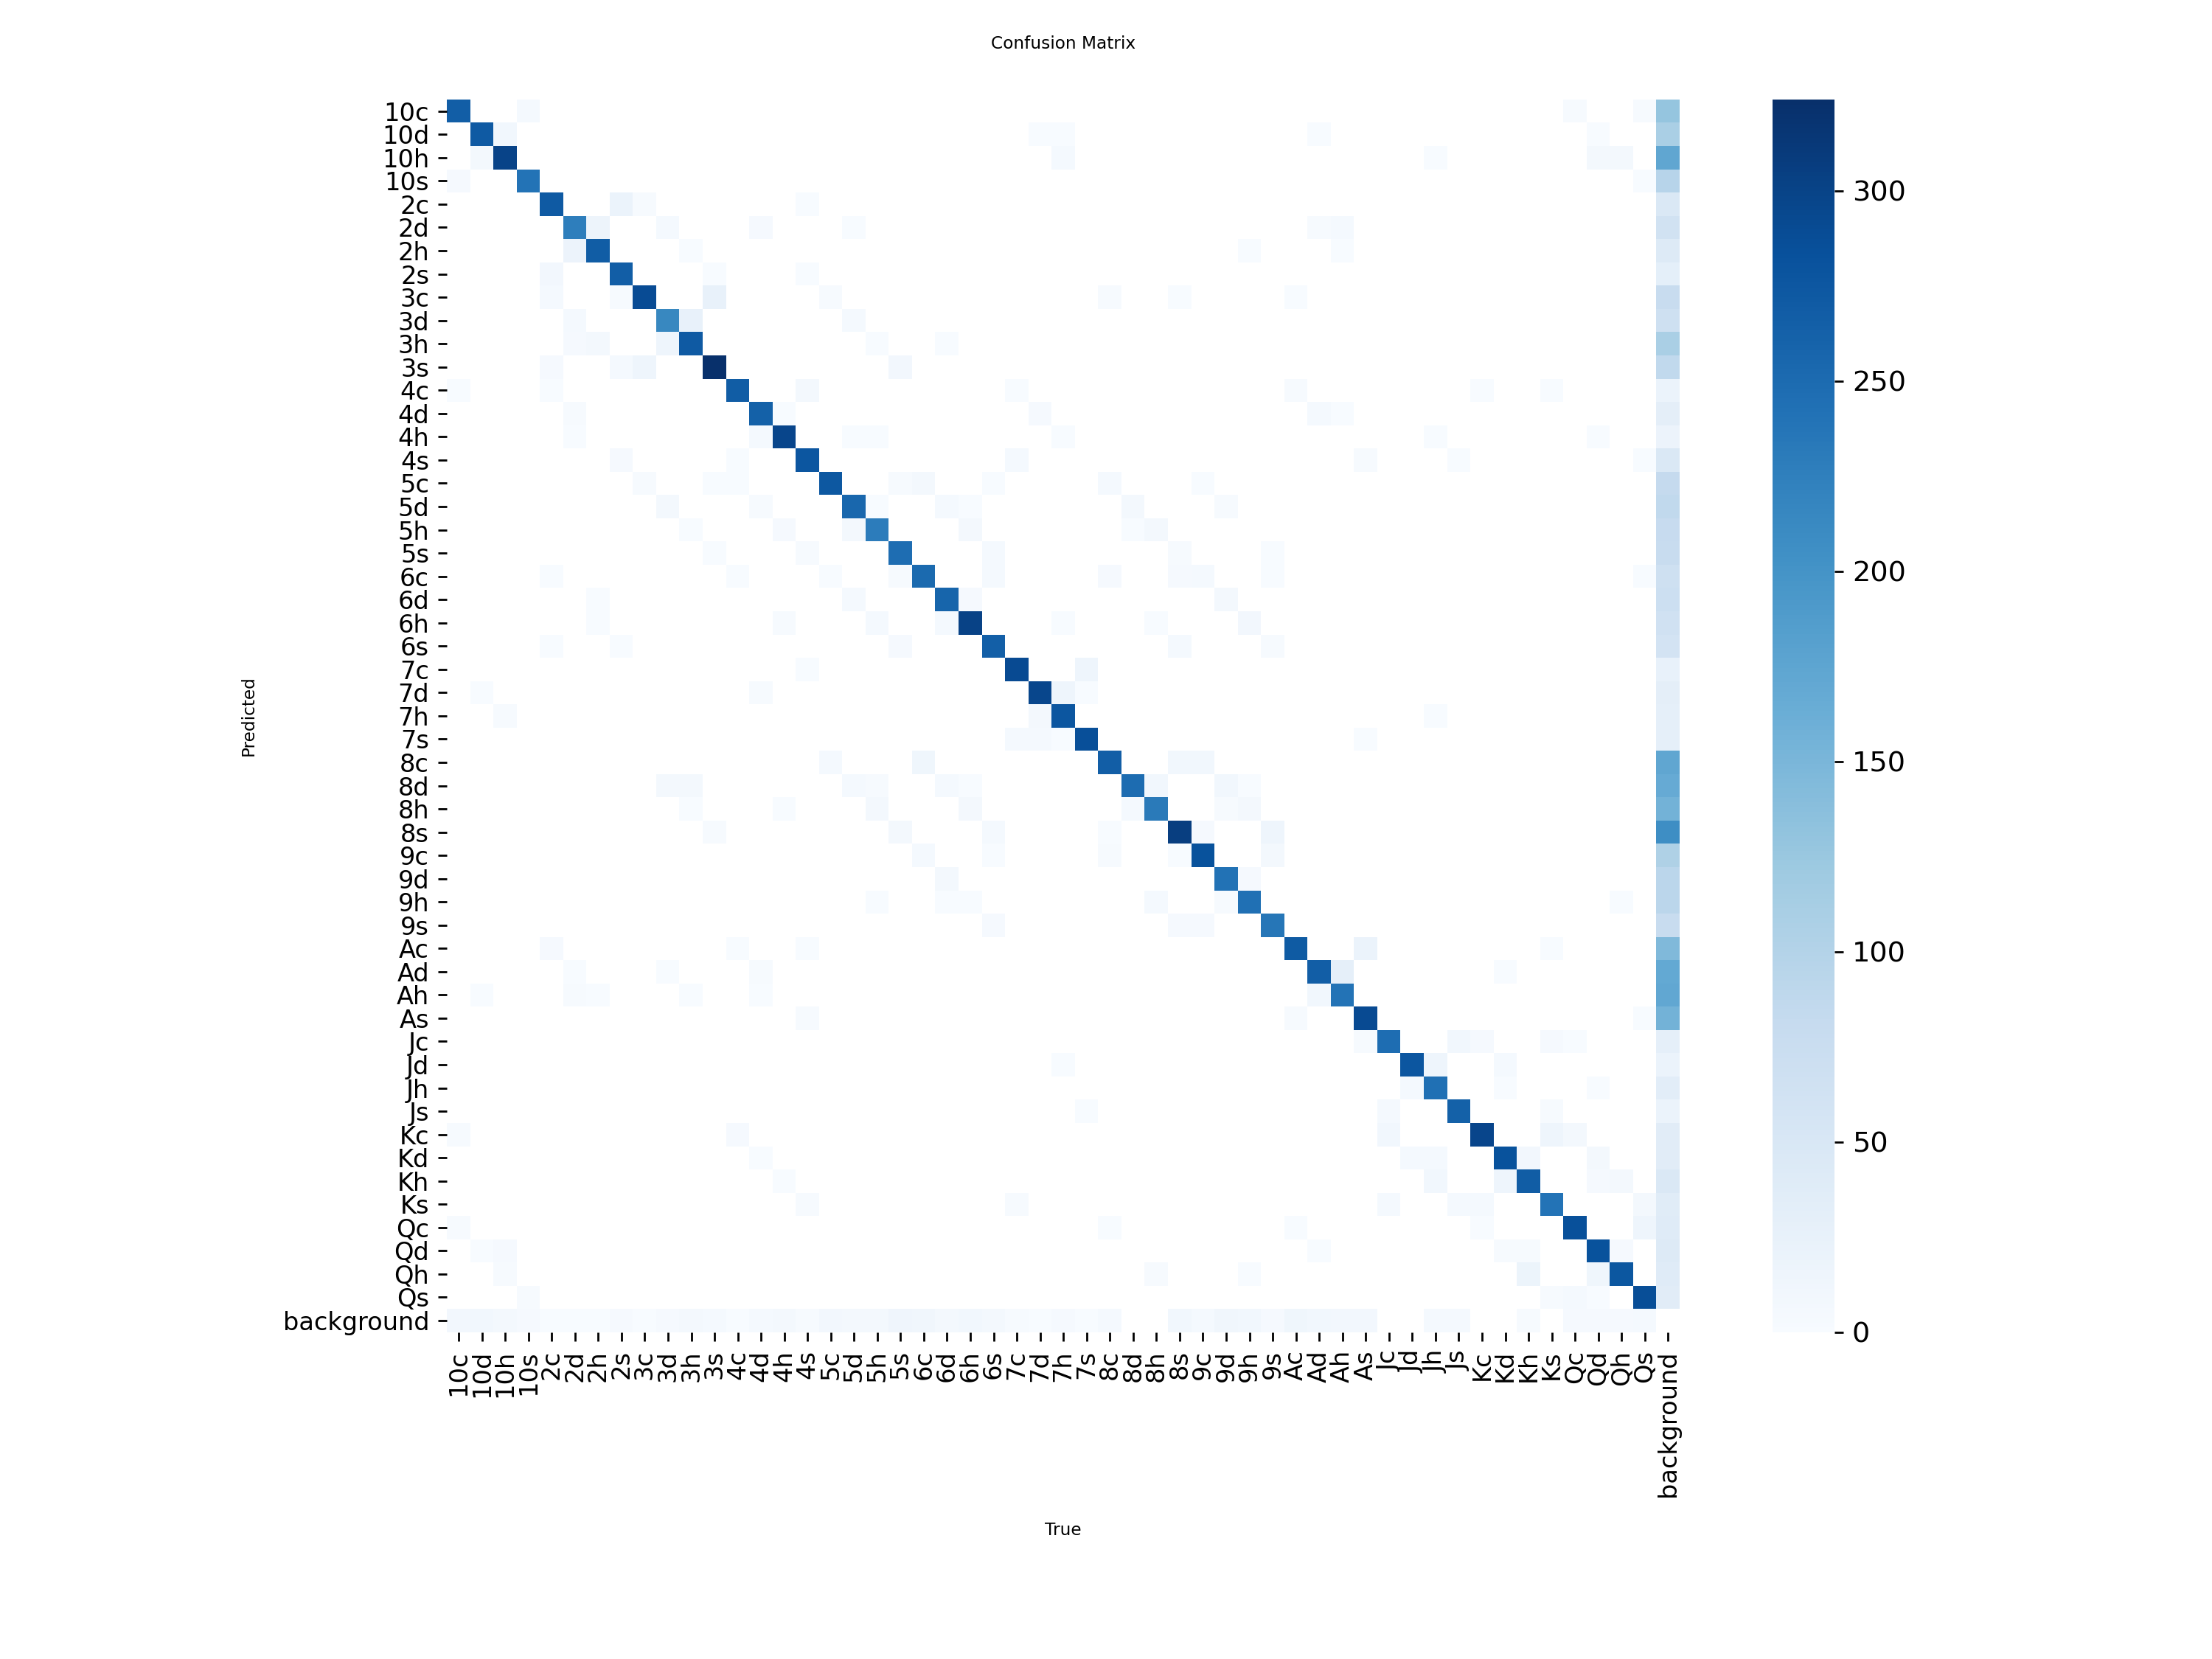

In [5]:
conf_matrix_path = '/work/csse463/202620/03/runs/detect/train26/confusion_matrix.png'
display(Image.open(conf_matrix_path))

In [ ]:
best_model = YOLO('/work/csse463/202620/03/runs/detect/train26/weights/best.pt')  # Load best trained weights

results = best_model.predict(
    source=test_path,  # Path to test images
    save=True,         # Save prediction images
    imgsz=416,         # Image size
    conf=0.25          # Confidence threshold
)

print(f"Visual results saved to: {results[0].save_dir}")  # Output directory


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2000 /work/csse463/202620/03/test/images/000246247_jpg.rf.fb915aef7c063ce2ac971f8de0d8b2c1.jpg: 416x416 2 7cs, 1 8d, 1 As, 7.7ms
image 2/2000 /work/csse463/202620/03/test/images/000355142_jpg.rf.7e5eff691d035112dd4b5021fe38a46c.jpg: 416x416 2 4ss, 1 8h, 1 Kh, 8.0ms
image 3/2000 /work/csse463/202620/03/test/images/001761433_jpg.rf.1a4a563beb6d588841bd8bd3a50c083b.jpg: 416x416 3 8cs, 4 8ds, 8.1ms
image 4/2000 /work/csse463/202620/03/test/images/002

In [10]:
stats = best_model.val(split='test', verbose=False)
print(f"Overall Precision: {stats.results_dict['metrics/precision(B)']:.3f}")
print(f"Overall Recall:    {stats.results_dict['metrics/recall(B)']:.3f}")
print(f"Overall mAP50:     {stats.results_dict['metrics/mAP50(B)']:.3f}")

Ultralytics 8.4.11 🚀 Python-3.11.2 torch-2.10.0+cu128 CUDA:0 (Quadro RTX 6000, 24023MiB)


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 28.2±9.1 MB/s, size: 32.4 KB)
val: Scanning /work/csse463/202620/03/test/labels.cache... 2000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 119.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 12.3it/s 10.1s0.1s
                   all       2000       7588      0.883      0.907      0.954      0.857
Speed: 0.3ms preprocess, 0.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /work/csse463/202620/03/runs/detect/val12
Overall Precision: 0.883
Overall Recall:    0.907
Overall mAP50:     0.954


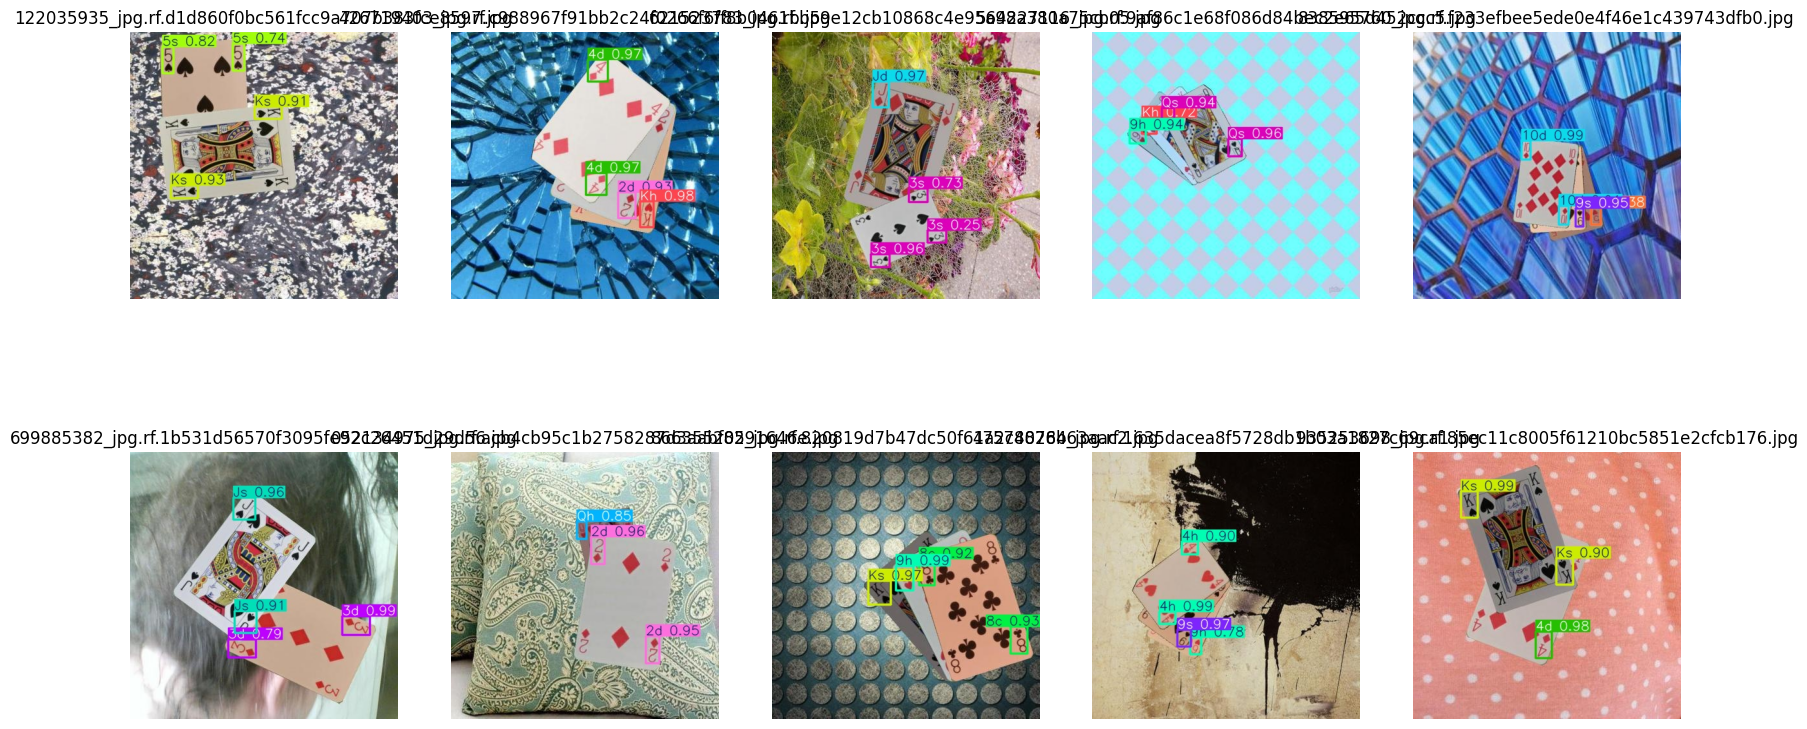

In [ ]:
predict_dir = '/work/csse463/202620/03/runs/detect/predict7'  # Directory with saved predictions

# Get all image files in directory
all_images = [f for f in os.listdir(predict_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

samples = random.sample(all_images, min(10, len(all_images)))  # Randomly select up to 10 images

plt.figure(figsize=(20, 10))
for i, img_name in enumerate(samples):
    img_path = os.path.join(predict_dir, img_name)
    img = Image.open(img_path)

    plt.subplot(2, 5, i + 1)  # 2x5 grid
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.show()